# Student Mental Health Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, recall_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (hamming_loss, f1_score,
                              classification_report)

## Load Dataset

In [2]:
url = 'https://raw.githubusercontent.com/alifnw/data-vault/refs/heads/main/Student%20Mental%20health.csv'

df = pd.read_csv(url)
df.head()

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [3]:
# Rename kolom biar lebih pendek
df.columns = [
    'Timestamp', 'Gender', 'Age', 'Course', 'Year',
    'CGPA', 'Marital_Status', 'Depression', 'Anxiety',
    'Panic_Attack', 'Seek_Treatment'
]

df.head()

,Timestamp,Gender,Age,Course,Year,CGPA,Marital_Status,Depression,Anxiety,Panic_Attack,Seek_Treatment
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


## Data Cleaning

In [4]:
df.drop(columns=["Timestamp"], inplace=True)

In [5]:
str_cols = df.select_dtypes(include="object").columns
df[str_cols] = df[str_cols].apply(lambda col: col.str.strip())

C:\Users\USER\AppData\Local\Temp\ipykernel_7444\1293939520.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include="object").columns


In [6]:
df["Year"] = df["Year"].str.title()

In [7]:
course_map = {
    # KOE variants
    "koe": "KOE",
    "Koe": "KOE",

    # KIRKHS variants
    "Irkhs": "KIRKHS",
    "Kirkhs": "KIRKHS",

    # Engineering variants
    "Engine": "Engineering",
    "engin": "Engineering",
    "ENM": "Engineering",

    # Pendidikan Islam variants
    "Pendidikan islam": "Pendidikan Islam",

    # Islamic Education variants
    "Islamic education": "Islamic Education",

    # BENL variants
    "Benl": "BENL",

    # Psychology variants
    "psychology": "Psychology",

    # Usuluddin (trailing space already stripped above)
    "Usuluddin": "Usuluddin",

    # Fiqh fatwa (trailing space already stripped above)
    "Fiqh fatwa": "Fiqh Fatwa",

    "Laws":"Law"
}

df["Course"] = df["Course"].replace(course_map)

In [8]:
for col in ["Year", "Course", "CGPA"]:
    print(f"\n{col} ({df[col].nunique()} unique):")
    print(sorted(df[col].unique()))


Year (4 unique):
['Year 1', 'Year 2', 'Year 3', 'Year 4']

Course (36 unique):
['ALA', 'Accounting', 'BCS', 'BENL', 'BIT', 'Banking Studies', 'Biomedical science', 'Biotechnology', 'Business Administration', 'CTS', 'Communication', 'DIPLOMA TESL', 'Diploma Nursing', 'Econs', 'Engineering', 'Fiqh', 'Fiqh Fatwa', 'Human Resources', 'Human Sciences', 'IT', 'Islamic Education', 'KENMS', 'KIRKHS', 'KOE', 'Kop', 'Law', 'MHSC', 'Malcom', 'Marine science', 'Mathemathics', 'Nursing', 'Pendidikan Islam', 'Psychology', 'Radiography', 'TAASL', 'Usuluddin']

CGPA (5 unique):
['0 - 1.99', '2.00 - 2.49', '2.50 - 2.99', '3.00 - 3.49', '3.50 - 4.00']


In [9]:
df.head()

,Gender,Age,Course,Year,CGPA,Marital_Status,Depression,Anxiety,Panic_Attack,Seek_Treatment
0,Female,18.0,Engineering,Year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,Male,21.0,Islamic Education,Year 2,3.00 - 3.49,No,No,Yes,No,No
2,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,Female,22.0,Law,Year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,Male,23.0,Mathemathics,Year 4,3.00 - 3.49,No,No,No,No,No


## Exploratory Data Analysis

### Basic Dataset Information

#### Info & Shape

In [10]:
print('Shape:', df.shape)
df.info()

Shape: (101, 10)
<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          101 non-null    str    
 1   Age             100 non-null    float64
 2   Course          101 non-null    str    
 3   Year            101 non-null    str    
 4   CGPA            101 non-null    str    
 5   Marital_Status  101 non-null    str    
 6   Depression      101 non-null    str    
 7   Anxiety         101 non-null    str    
 8   Panic_Attack    101 non-null    str    
 9   Seek_Treatment  101 non-null    str    
dtypes: float64(1), str(9)
memory usage: 12.2 KB


#### Missing Values

In [11]:
print('Missing values per kolom:')
print(df.isnull().sum())
print()
print('Total missing:', df.isnull().sum().sum())

Missing values per kolom:
Gender            0
Age               1
Course            0
Year              0
CGPA              0
Marital_Status    0
Depression        0
Anxiety           0
Panic_Attack      0
Seek_Treatment    0
dtype: int64

Total missing: 1


In [12]:
# fill missing with median
df['Age'] = df['Age'].fillna(df['Age'].median())
print('Missing values per kolom:')
print(df.isnull().sum())
print()
print('Total missing:', df.isnull().sum().sum())

Missing values per kolom:
Gender            0
Age               0
Course            0
Year              0
CGPA              0
Marital_Status    0
Depression        0
Anxiety           0
Panic_Attack      0
Seek_Treatment    0
dtype: int64

Total missing: 0


In [13]:
print(f"Jumlah baris duplikat sebelum dihapus: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Shape dataset setelah menghapus duplikat: {df.shape}")


Jumlah baris duplikat sebelum dihapus: 1
Shape dataset setelah menghapus duplikat: (100, 10)


In [14]:
for col in df.columns:
    print(f"Feature: {col}")
    print(f"Unique Count: {df[col].nunique()}")
    print(f"Unique Values: {df[col].unique()}")
    print('-' * 30)

Feature: Gender
Unique Count: 2
Unique Values: <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
------------------------------
Feature: Age
Unique Count: 7
Unique Values: [18. 21. 19. 22. 23. 20. 24.]
------------------------------
Feature: Course
Unique Count: 36
Unique Values: <ArrowStringArray>
[            'Engineering',       'Islamic Education',
                     'BIT',                     'Law',
            'Mathemathics',        'Pendidikan Islam',
                     'BCS',         'Human Resources',
                  'KIRKHS',              'Psychology',
                   'KENMS',              'Accounting',
          'Marine science',                     'KOE',
         'Banking Studies', 'Business Administration',
               'Usuluddin',                   'TAASL',
                     'ALA',      'Biomedical science',
                    'BENL',                      'IT',
                     'CTS',                   'Econs',
                    'MHSC',   

#### Statistik Deskriptif

In [15]:
df.describe()

,Age
count,100.000000
mean,20.540000
std,2.488032
min,18.000000
25%,18.000000
50%,19.000000
75%,23.000000
max,24.000000


### Univariate Analysis

#### Distribusi Usia

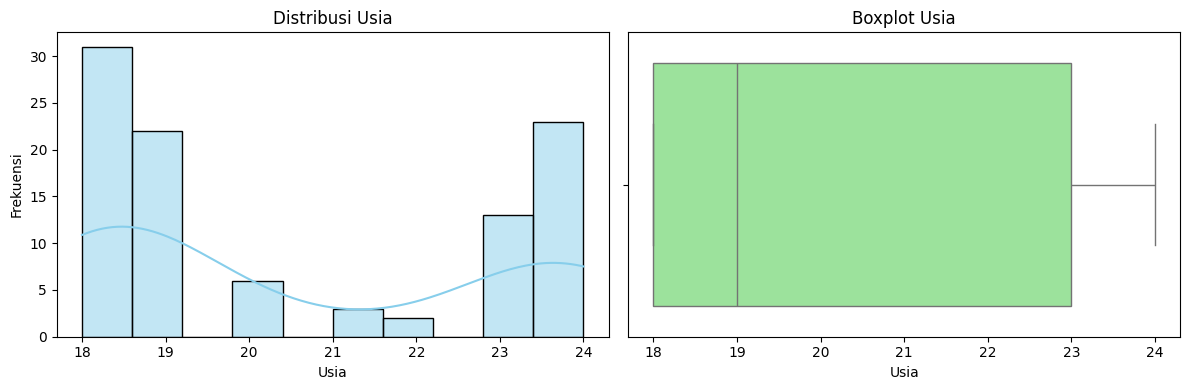

Mean Usia : 20.54
Median Usia: 19.0
Std Usia  : 2.49


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram with Seaborn
sns.histplot(df['Age'], bins=10, kde=True, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Distribusi Usia')
axes[0].set_xlabel('Usia')
axes[0].set_ylabel('Frekuensi')

# Boxplot with Seaborn
sns.boxplot(x=df['Age'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot Usia')
axes[1].set_xlabel('Usia')

plt.tight_layout()
plt.show()

print('Mean Usia :', round(df['Age'].mean(), 2))
print('Median Usia:', df['Age'].median())
print('Std Usia  :', round(df['Age'].std(), 2))

#### Distribusi Gender

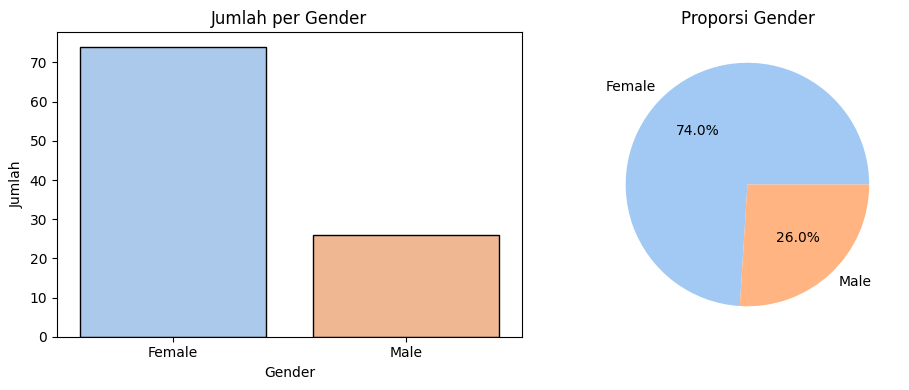

In [17]:
gender_counts = df['Gender'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Countplot with Seaborn - Fixed FutureWarning
sns.countplot(data=df, x='Gender', hue='Gender', ax=axes[0], palette='pastel', edgecolor='black', legend=False)
axes[0].set_title('Jumlah per Gender')
axes[0].set_ylabel('Jumlah')

# Pie chart
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
axes[1].set_title('Proporsi Gender')

plt.tight_layout()
plt.show()

#### Distribusi Tahun Studi & CGPA

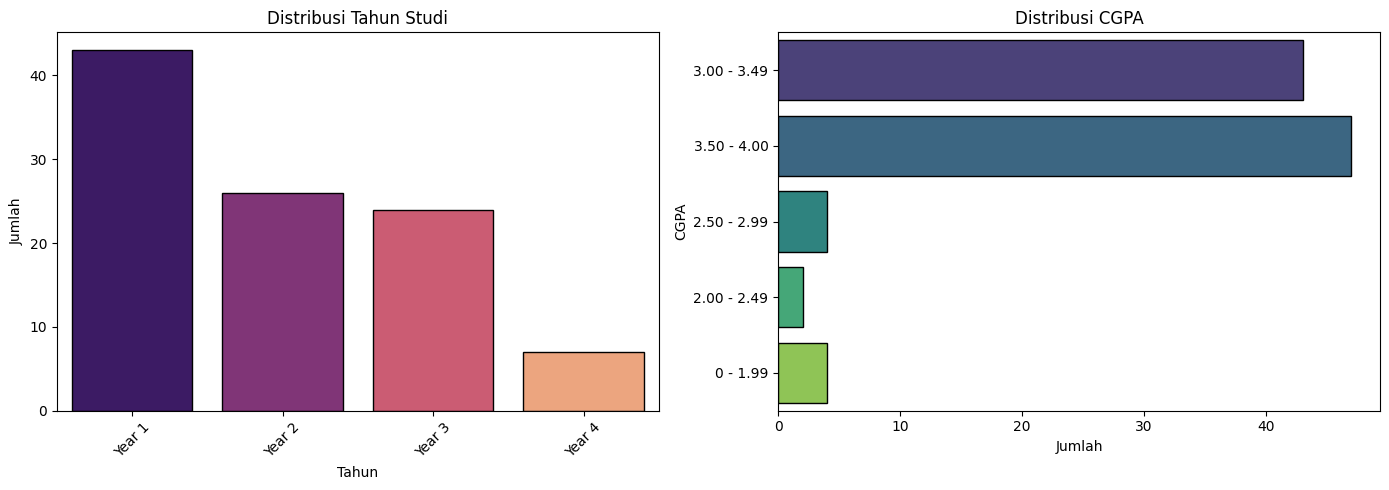

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot for Study Year - Fixed FutureWarning
sns.countplot(data=df, x='Year', hue='Year', ax=axes[0], palette='magma', edgecolor='black', order=sorted(df['Year'].unique()), legend=False)
axes[0].set_title('Distribusi Tahun Studi')
axes[0].set_xlabel('Tahun')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=45)

# Countplot for CGPA - Fixed FutureWarning
sns.countplot(data=df, y='CGPA', hue='CGPA', ax=axes[1], palette='viridis', edgecolor='black', legend=False)
axes[1].set_title('Distribusi CGPA')
axes[1].set_xlabel('Jumlah')

plt.tight_layout()
plt.show()

#### Prevalensi Masalah Kesehatan Mental

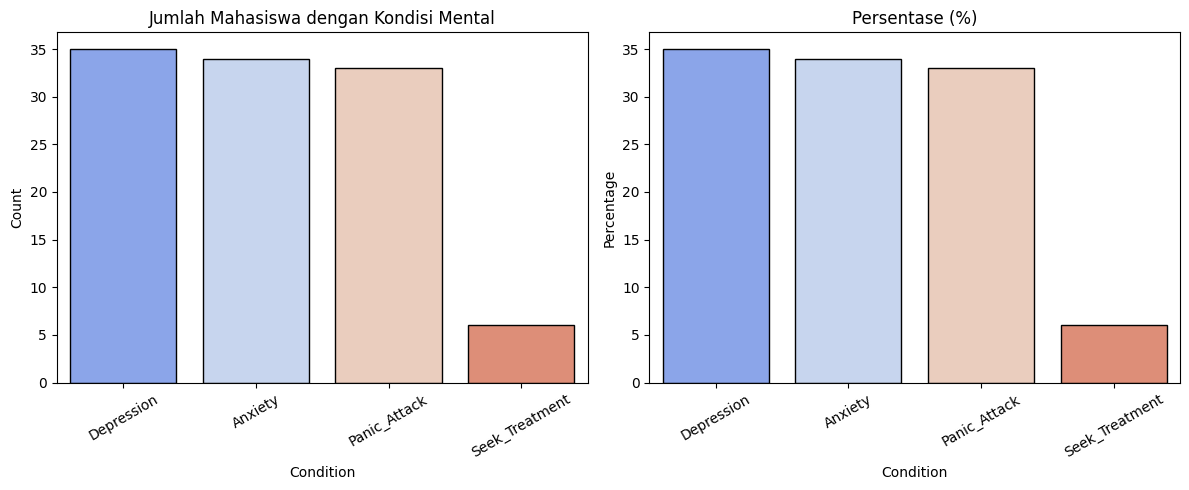

In [19]:
mental_health_cols = ['Depression', 'Anxiety', 'Panic_Attack', 'Seek_Treatment']
prevalence_data = pd.DataFrame({
    'Condition': mental_health_cols,
    'Count': [(df[col] == 'Yes').sum() for col in mental_health_cols],
    'Percentage': [(df[col] == 'Yes').mean() * 100 for col in mental_health_cols]
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=prevalence_data, x='Condition', y='Count', ax=axes[0], palette='coolwarm', edgecolor='black', hue='Condition', legend=False)
axes[0].set_title('Jumlah Mahasiswa dengan Kondisi Mental')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=prevalence_data, x='Condition', y='Percentage', ax=axes[1], palette='coolwarm', edgecolor='black', hue='Condition', legend=False)
axes[1].set_title('Persentase (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

#### 10 Jurusan Terbanyak

Course
Engineering           20
BCS                   18
BIT                   10
KOE                    6
Biomedical science     4
Law                    3
Pendidikan Islam       3
KIRKHS                 3
Psychology             3
BENL                   3
Name: count, dtype: int64


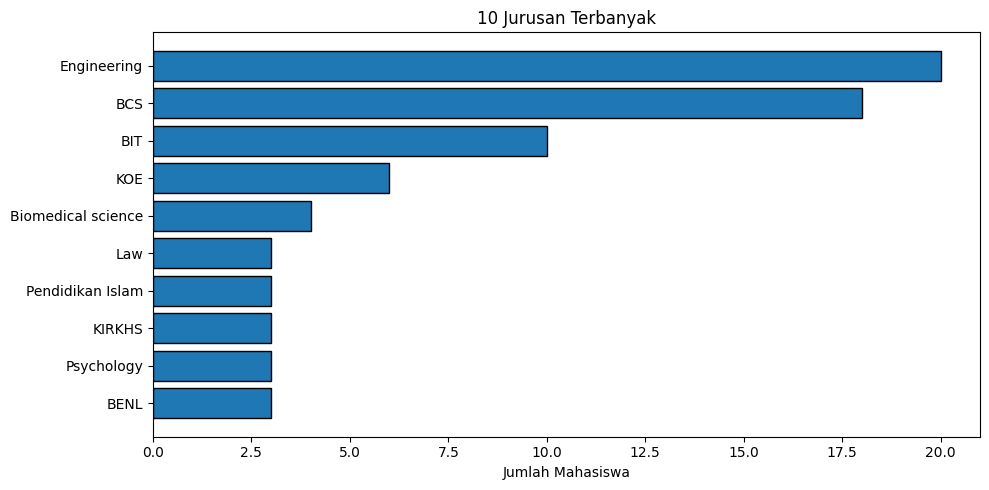

In [20]:
top_courses = df['Course'].value_counts().head(10)
print(top_courses)

plt.figure(figsize=(10, 5))
plt.barh(top_courses.index[::-1], top_courses.values[::-1], edgecolor='black')
plt.title('10 Jurusan Terbanyak')
plt.xlabel('Jumlah Mahasiswa')
plt.tight_layout()
plt.show()

#### Target

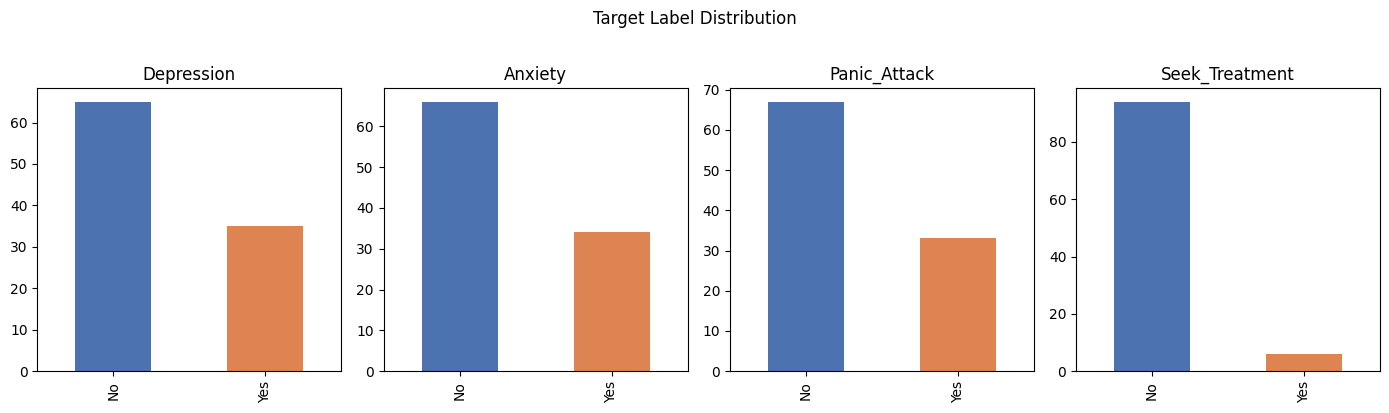


Label Co-occurrence Matrix:
                Depression  Anxiety  Panic_Attack  Seek_Treatment
Depression              35       18            17               6
Anxiety                 18       34            13               3
Panic_Attack            17       13            33               4
Seek_Treatment           6        3             4               6


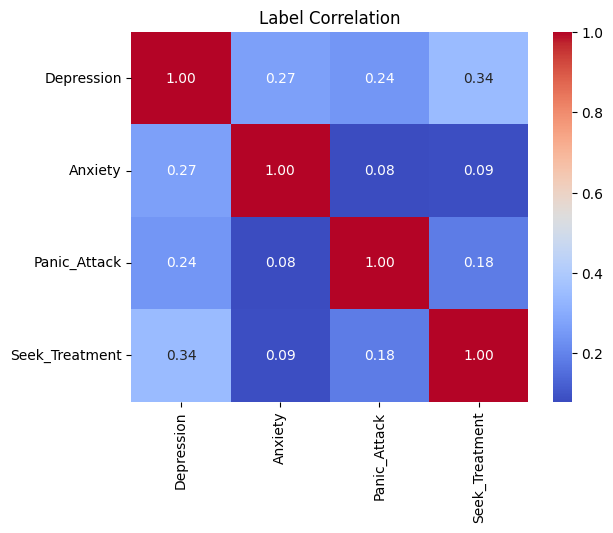

In [21]:
targets = ["Depression", "Anxiety", "Panic_Attack", "Seek_Treatment"]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, targets):
    df[col].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0","#DD8452"])
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Target Label Distribution", y=1.02)
plt.tight_layout()
plt.show()

# ── 2.2 Label co-occurrence (how often labels appear together) ──────
target_encoded = df[targets].apply(lambda col: col.map({"Yes": 1, "No": 0}))
print("\nLabel Co-occurrence Matrix:")
print(target_encoded.T.dot(target_encoded))

sns.heatmap(target_encoded.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Label Correlation")
plt.show()


### Bivariate Analysis

#### Kondisi Mental Berdasarkan Gender

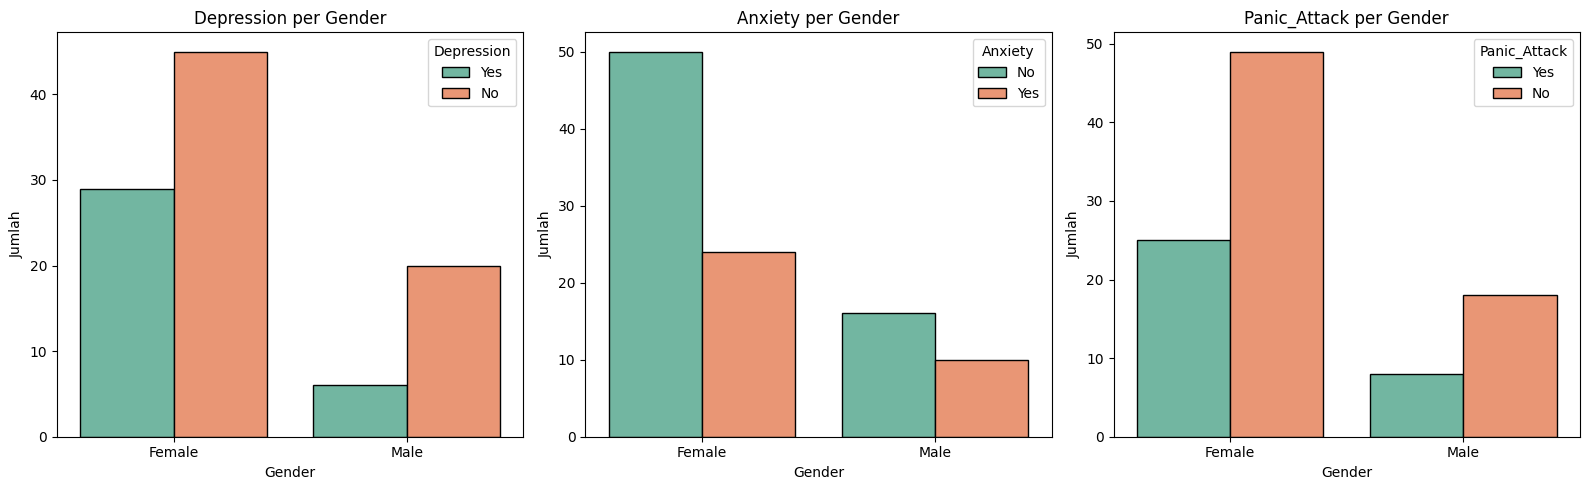

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

mental_health_indicators = ['Depression', 'Anxiety', 'Panic_Attack']

for i, col in enumerate(mental_health_indicators):
    sns.countplot(data=df, x='Gender', hue=col, ax=axes[i], palette='Set2', edgecolor='black')
    axes[i].set_title(f'{col} per Gender')
    axes[i].set_xlabel('Gender')
    axes[i].set_ylabel('Jumlah')
    axes[i].legend(title=col)

plt.tight_layout()
plt.show()

#### Analisis Statistik: Chi-Square Test (Gender vs. Kondisi Mental)

Kita akan menggunakan Chi-square test untuk melihat apakah ada hubungan yang signifikan antara Gender dengan kondisi mental (Depression, Anxiety, Panic Attack).

In [23]:
from scipy.stats import chi2_contingency

print('Chi-square test untuk Gender vs. Kondisi Mental:')

mental_health_cols = ['Depression', 'Anxiety', 'Panic_Attack']

for col in mental_health_cols:
    contingency_table = pd.crosstab(df['Gender'], df[col])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print(f'\n--- {col} vs. Gender ---')
    print('Tabel Kontingensi:')
    print(contingency_table)
    print(f'Chi2: {chi2:.2f}')
    print(f'P-value: {p_value:.3f}')
    if p_value < 0.05:
        print('Ada hubungan yang signifikan (p < 0.05)')
    else:
        print('Tidak ada hubungan yang signifikan (p >= 0.05)')

Chi-square test untuk Gender vs. Kondisi Mental:

--- Depression vs. Gender ---
Tabel Kontingensi:
Depression  No  Yes
Gender             
Female      45   29
Male        20    6
Chi2: 1.54
P-value: 0.214
Tidak ada hubungan yang signifikan (p >= 0.05)

--- Anxiety vs. Gender ---
Tabel Kontingensi:
Anxiety  No  Yes
Gender          
Female   50   24
Male     16   10
Chi2: 0.10
P-value: 0.751
Tidak ada hubungan yang signifikan (p >= 0.05)

--- Panic_Attack vs. Gender ---
Tabel Kontingensi:
Panic_Attack  No  Yes
Gender               
Female        49   25
Male          18    8
Chi2: 0.00
P-value: 0.969
Tidak ada hubungan yang signifikan (p >= 0.05)


#### Visualisasi Mental Health Condition vs Gender


C:\Users\USER\AppData\Local\Temp\ipykernel_7444\2524044360.py:5: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  ct_pct = ct.div(ct.sum(1).astype(float), axis=0)
C:\Users\USER\AppData\Local\Temp\ipykernel_7444\2524044360.py:5: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  ct_pct = ct.div(ct.sum(1).astype(float), axis=0)
C:\Users\USER\AppData\Local\Temp\ipykernel_7444\2524044360.py:5: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  ct_pct = ct.div(ct.sum(1).astype(float), axis=0)


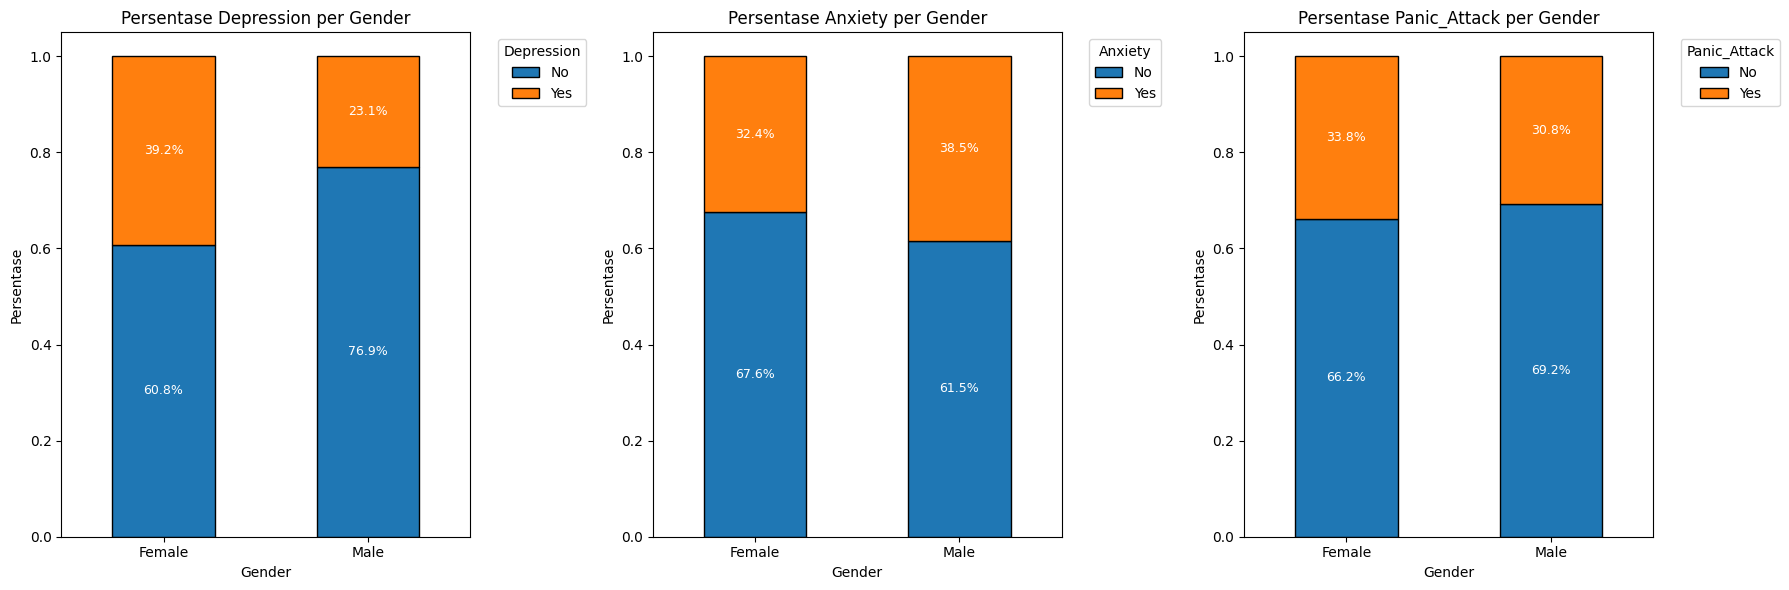

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(['Depression', 'Anxiety', 'Panic_Attack']):
    ct = pd.crosstab(df['Gender'], df[col])
    ct_pct = ct.div(ct.sum(1).astype(float), axis=0)

    ct_pct.plot(kind='bar', stacked=True, ax=axes[i], edgecolor='black')
    axes[i].set_title(f'Persentase {col} per Gender')
    axes[i].set_xlabel('Gender')
    axes[i].set_ylabel('Persentase')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')

    # Annotate bars with percentages
    for container in axes[i].containers:
        for j, rect in enumerate(container):
            height = rect.get_height()
            width = rect.get_width()
            x = rect.get_x()
            y = rect.get_y()
            if height > 0.01: # Only annotate significant percentages
                axes[i].text(x + width/2, y + height/2, f'{height*100:.1f}%',
                             ha='center', va='center', color='white', fontsize=9)

plt.tight_layout()
plt.show()

#### Komorbiditas Kondisi Mental

Kita akan melihat berapa banyak mahasiswa yang memiliki 2 atau 3 kondisi mental (Depression, Anxiety, Panic Attack) secara bersamaan.


Distribusi jumlah kondisi mental per mahasiswa:
Num_Conditions
0    36
1    36
2    18
3    10
Name: count, dtype: int64

Jumlah mahasiswa dengan 2 kondisi: 18 (18.0%)
Jumlah mahasiswa dengan 3 kondisi: 10 (10.0%)


C:\Users\USER\AppData\Local\Temp\ipykernel_7444\2165106617.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Num_Conditions', data=df_encoded, palette='viridis', edgecolor='black')


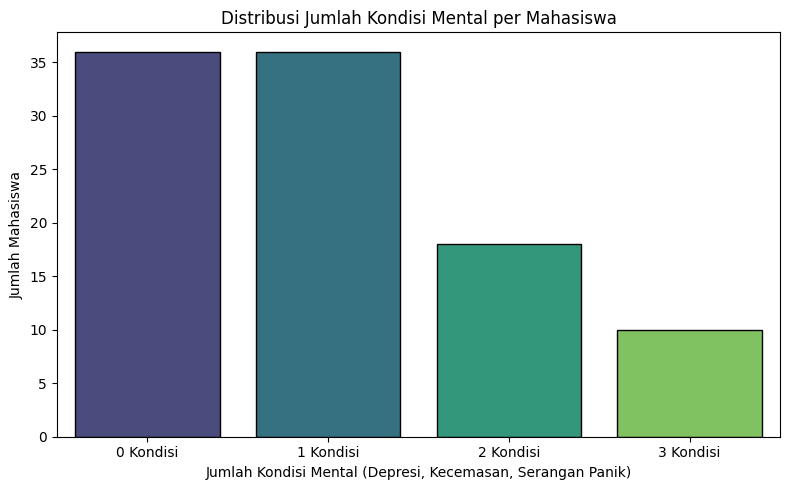

In [25]:
# Menghitung jumlah kondisi mental per mahasiswa
mental_health_cols = ['Depression', 'Anxiety', 'Panic_Attack']
df_encoded = df.copy()
for col in mental_health_cols:
    df_encoded[col] = (df_encoded[col] == 'Yes').astype(int)

df_encoded['Num_Conditions'] = df_encoded[mental_health_cols].sum(axis=1)
comorbidity_counts = df_encoded['Num_Conditions'].value_counts().sort_index()

print('Distribusi jumlah kondisi mental per mahasiswa:')
print(comorbidity_counts)

total_students = len(df_encoded)
students_with_2_conditions = comorbidity_counts.get(2, 0)
students_with_3_conditions = comorbidity_counts.get(3, 0)

print(f'\nJumlah mahasiswa dengan 2 kondisi: {students_with_2_conditions} ({students_with_2_conditions/total_students*100:.1f}%)')
print(f'Jumlah mahasiswa dengan 3 kondisi: {students_with_3_conditions} ({students_with_3_conditions/total_students*100:.1f}%)')

plt.figure(figsize=(8, 5))
sns.countplot(x='Num_Conditions', data=df_encoded, palette='viridis', edgecolor='black')
plt.title('Distribusi Jumlah Kondisi Mental per Mahasiswa')
plt.xlabel('Jumlah Kondisi Mental (Depresi, Kecemasan, Serangan Panik)')
plt.ylabel('Jumlah Mahasiswa')
plt.xticks(ticks=[0, 1, 2, 3], labels=['0 Kondisi', '1 Kondisi', '2 Kondisi', '3 Kondisi'])
plt.tight_layout()
plt.show()


#### Kondisi Mental Berdasarkan Tahun Studi

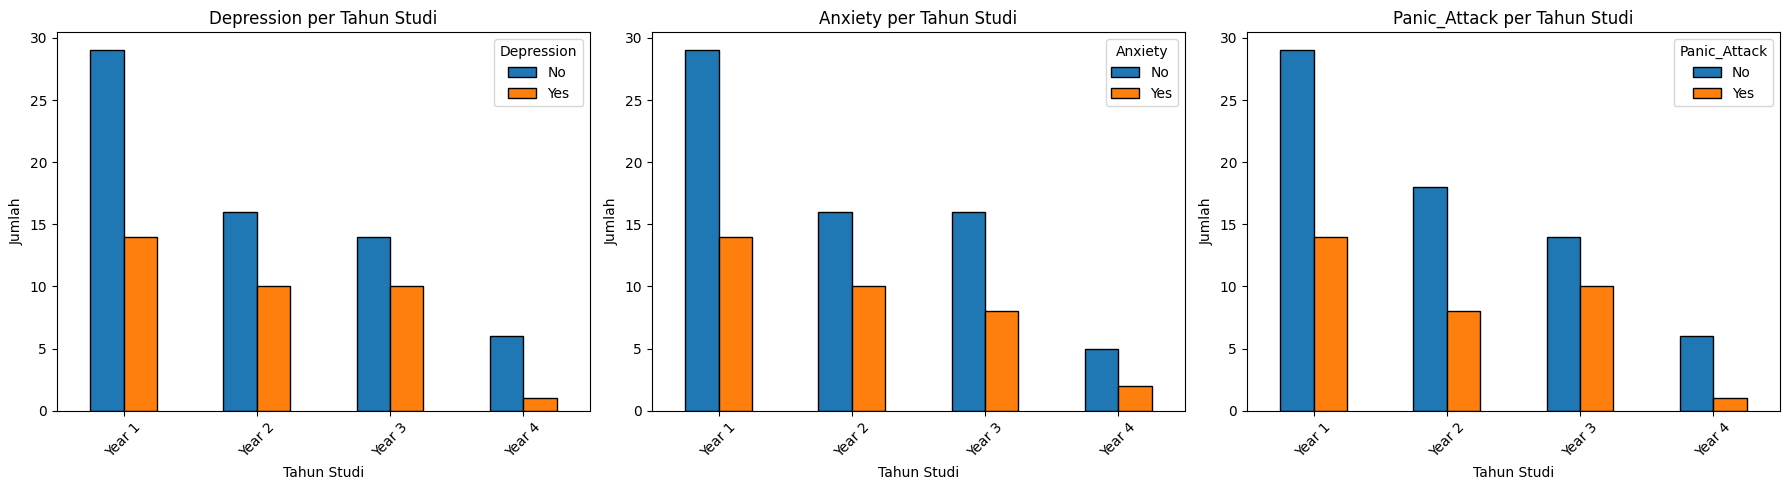

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['Depression', 'Anxiety', 'Panic_Attack']):
    ct = pd.crosstab(df['Year'], df[col])
    ct.plot(kind='bar', ax=axes[i], edgecolor='black')
    axes[i].set_title(f'{col} per Tahun Studi')
    axes[i].set_xlabel('Tahun Studi')
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title=col)

plt.tight_layout()
plt.show()

#### Kondisi Mental Berdasarkan CGPA

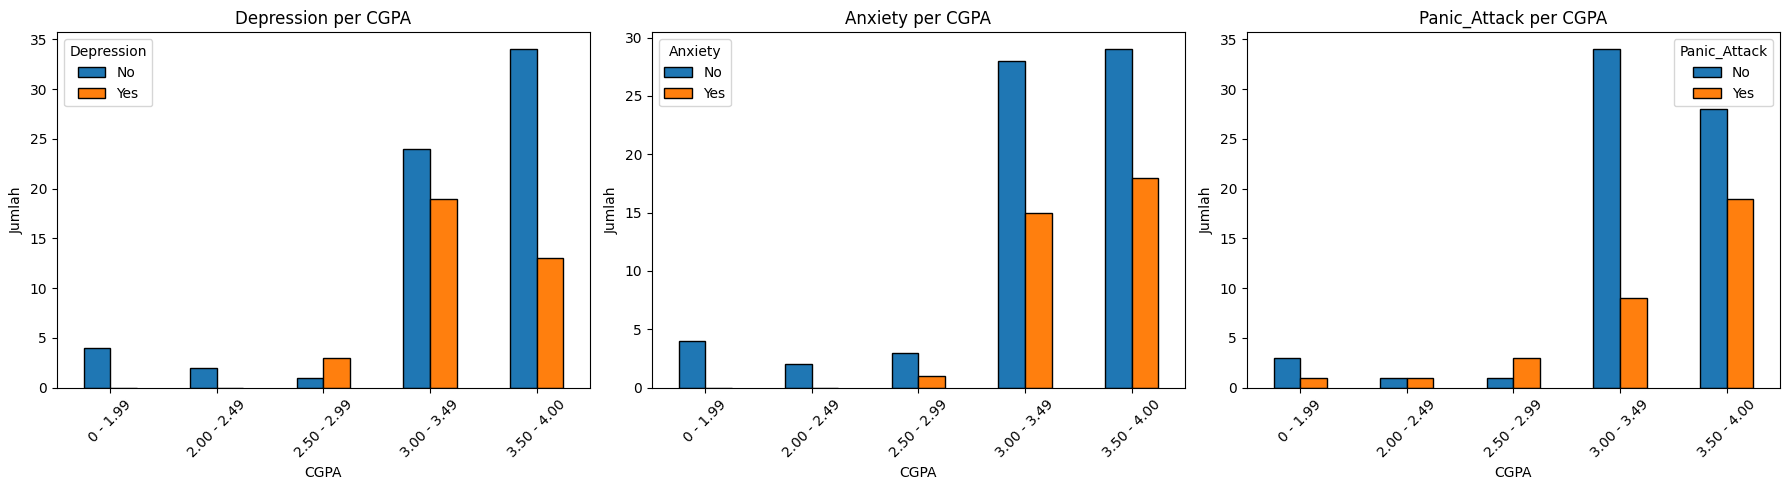

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['Depression', 'Anxiety', 'Panic_Attack']):
    ct = pd.crosstab(df['CGPA'], df[col])
    ct.plot(kind='bar', ax=axes[i], edgecolor='black')
    axes[i].set_title(f'{col} per CGPA')
    axes[i].set_xlabel('CGPA')
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title=col)

plt.tight_layout()
plt.show()

#### Mahasiswa yang Mencari Bantuan Berdasarkan Kondisi Mental

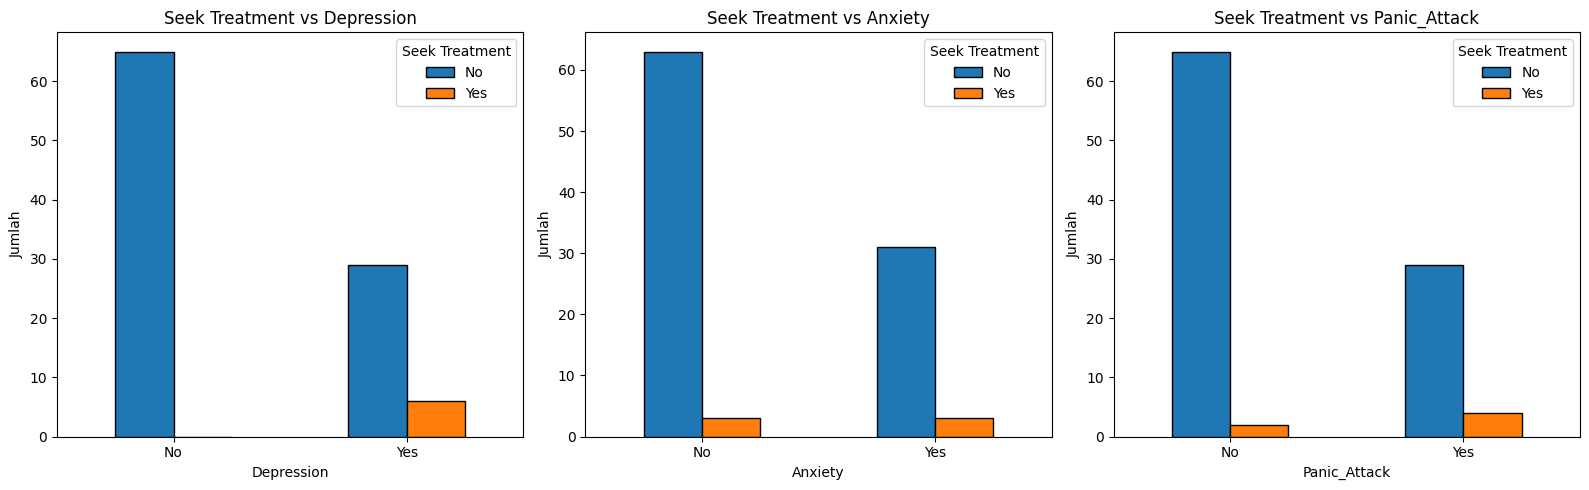

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(['Depression', 'Anxiety', 'Panic_Attack']):
    ct = pd.crosstab(df[col], df['Seek_Treatment'])
    ct.plot(kind='bar', ax=axes[i], edgecolor='black')
    axes[i].set_title(f'Seek Treatment vs {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title='Seek Treatment')

plt.tight_layout()
plt.show()

### Multivariate Analysis

#### Korelasi Antar Kondisi Mental (Heatmap)

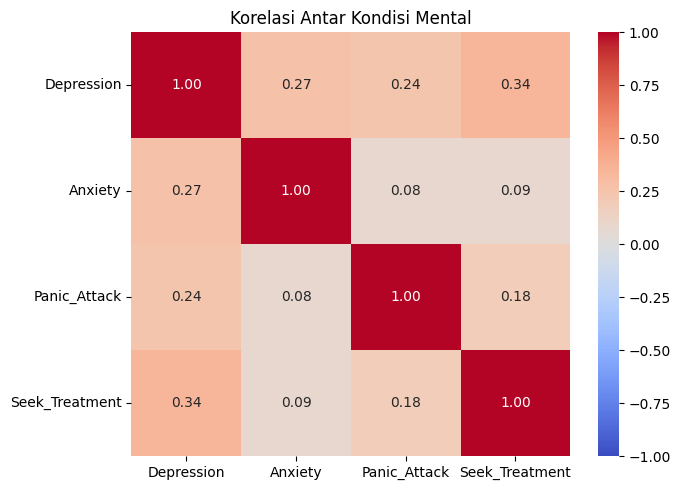

In [29]:
# Encode Yes/No ke 1/0
binary_cols = ['Depression', 'Anxiety', 'Panic_Attack', 'Seek_Treatment']
df_encoded = df[binary_cols].copy()
for col in binary_cols:
    df_encoded[col] = (df_encoded[col] == 'Yes').astype(int)

corr = df_encoded.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Korelasi Antar Kondisi Mental')
plt.tight_layout()
plt.show()

### Ringkasan EDA

#### Visualisasi Missing Values


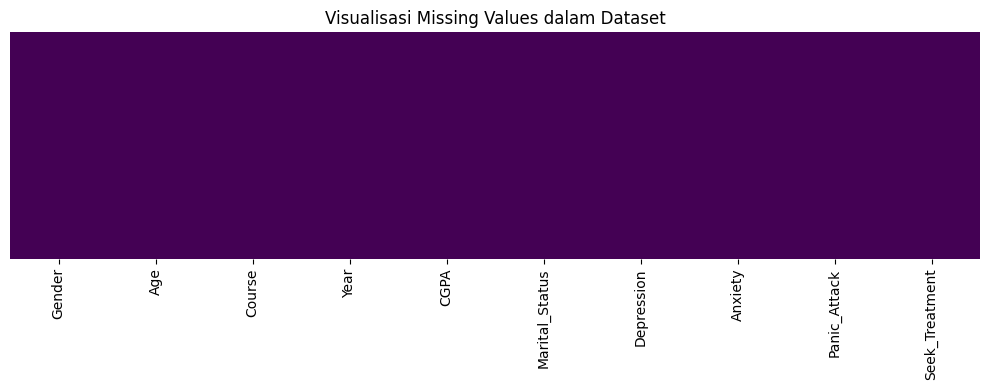

In [30]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Visualisasi Missing Values dalam Dataset")
plt.tight_layout()
plt.show()


#### Distribusi Usia vs Kondisi Mental


C:\Users\USER\AppData\Local\Temp\ipykernel_7444\152593558.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=col, y='Age', ax=axes[idx], palette='Set2')
C:\Users\USER\AppData\Local\Temp\ipykernel_7444\152593558.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=col, y='Age', ax=axes[idx], palette='Set2')
C:\Users\USER\AppData\Local\Temp\ipykernel_7444\152593558.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x=col, y='Age', ax=axes[idx], palette='Set2')


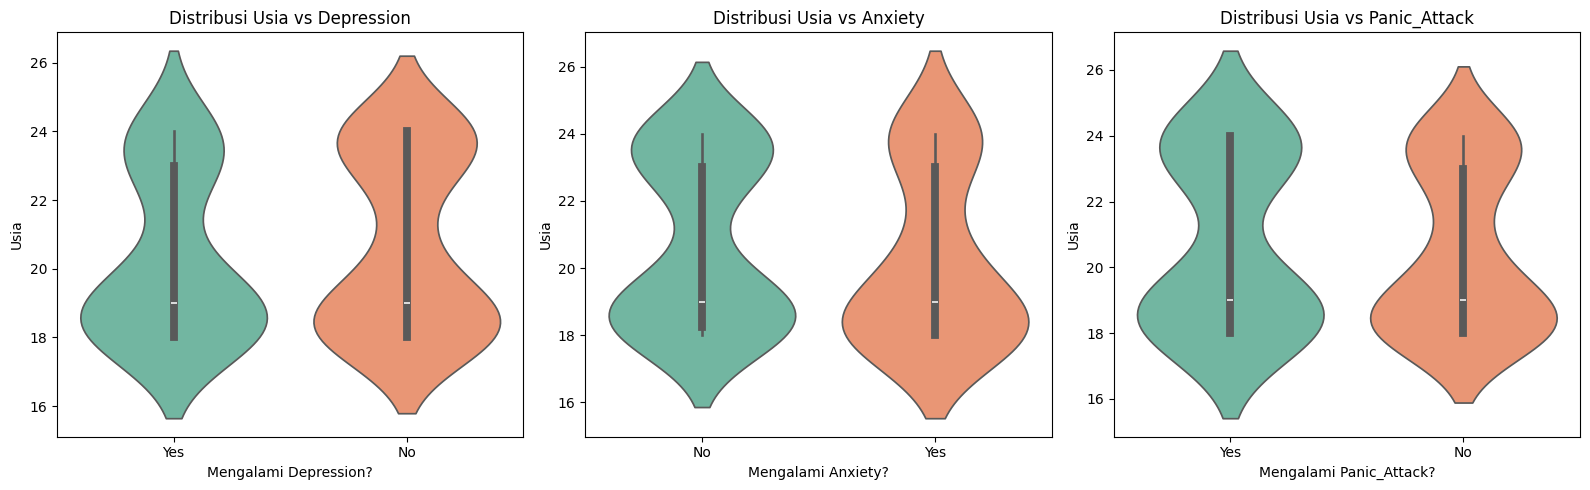

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for idx, col in enumerate(['Depression', 'Anxiety', 'Panic_Attack']):
    sns.violinplot(data=df, x=col, y='Age', ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'Distribusi Usia vs {col}')
    axes[idx].set_xlabel(f'Mengalami {col}?')
    axes[idx].set_ylabel('Usia')
plt.tight_layout()
plt.show()


#### Kondisi Mental vs Tahun Studi (Persentase)


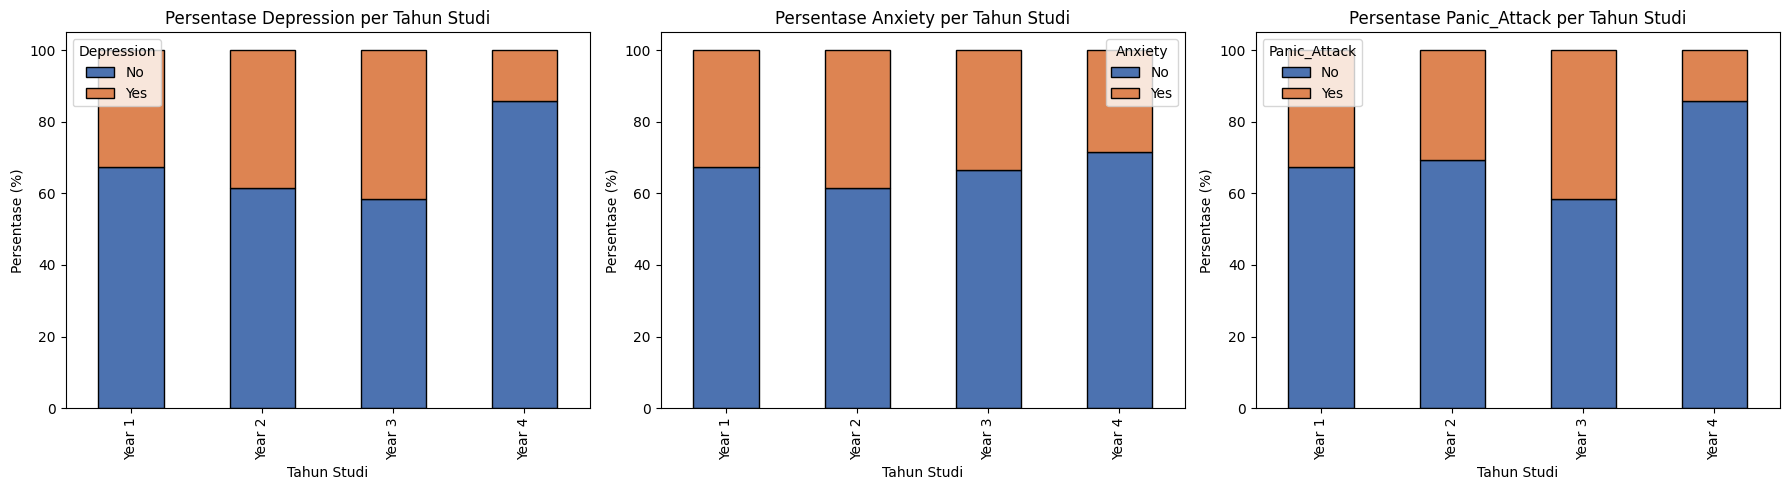

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, col in enumerate(['Depression', 'Anxiety', 'Panic_Attack']):
    ct = pd.crosstab(df['Year'], df[col], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[idx], color=['#4C72B0', '#DD8452'], edgecolor='black')
    axes[idx].set_title(f'Persentase {col} per Tahun Studi')
    axes[idx].set_xlabel('Tahun Studi')
    axes[idx].set_ylabel('Persentase (%)')
    axes[idx].legend(title=col)
plt.tight_layout()
plt.show()


#### Kondisi Mental vs CGPA (Persentase)


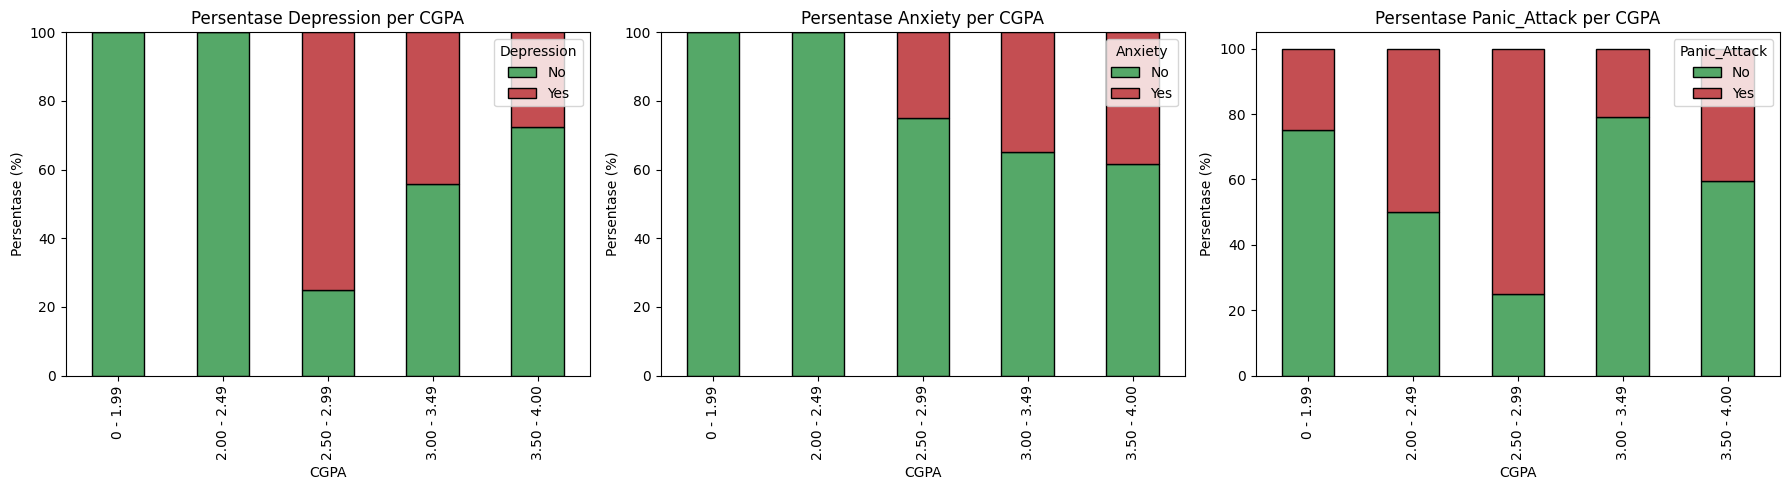

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, col in enumerate(['Depression', 'Anxiety', 'Panic_Attack']):
    ct = pd.crosstab(df['CGPA'], df[col], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[idx], color=['#55A868', '#C44E52'], edgecolor='black')
    axes[idx].set_title(f'Persentase {col} per CGPA')
    axes[idx].set_xlabel('CGPA')
    axes[idx].set_ylabel('Persentase (%)')
    axes[idx].legend(title=col)
plt.tight_layout()
plt.show()


#### Kondisi Mental vs Status Pernikahan


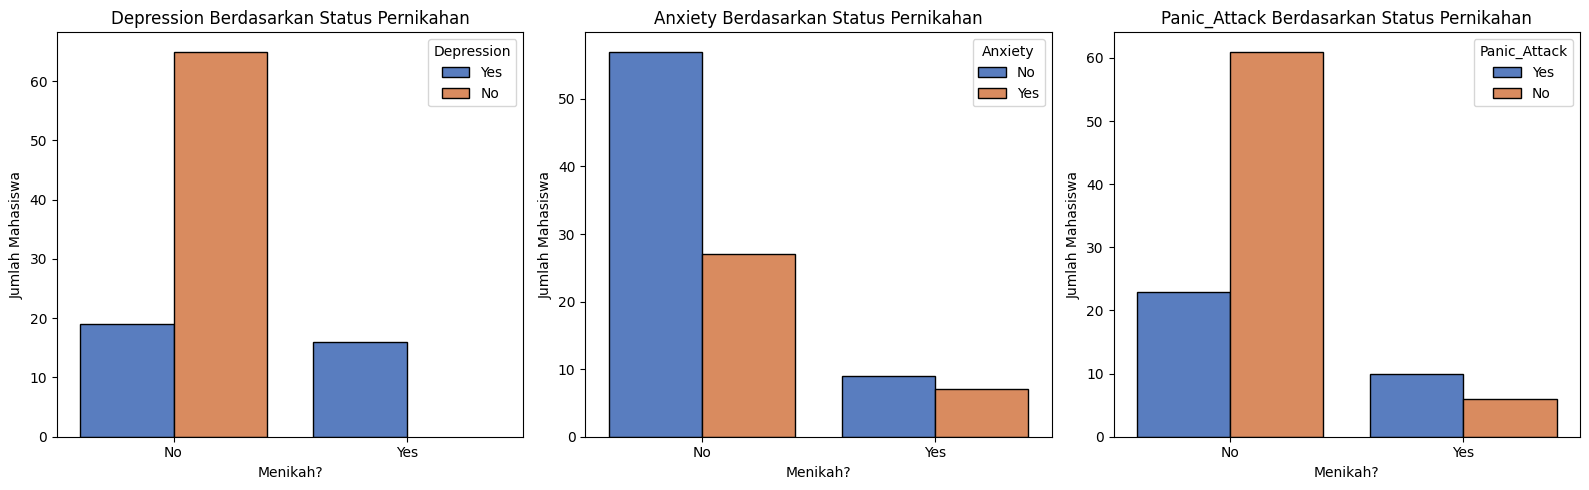

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for idx, col in enumerate(['Depression', 'Anxiety', 'Panic_Attack']):
    sns.countplot(data=df, x='Marital_Status', hue=col, ax=axes[idx], palette='muted', edgecolor='black')
    axes[idx].set_title(f'{col} Berdasarkan Status Pernikahan')
    axes[idx].set_xlabel('Menikah?')
    axes[idx].set_ylabel('Jumlah Mahasiswa')
plt.tight_layout()
plt.show()


#### Profil Kombinasi Kondisi Kesehatan Mental


C:\Users\USER\AppData\Local\Temp\ipykernel_7444\3014730654.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profile_counts.values, y=profile_counts.index, palette='coolwarm', edgecolor='black')


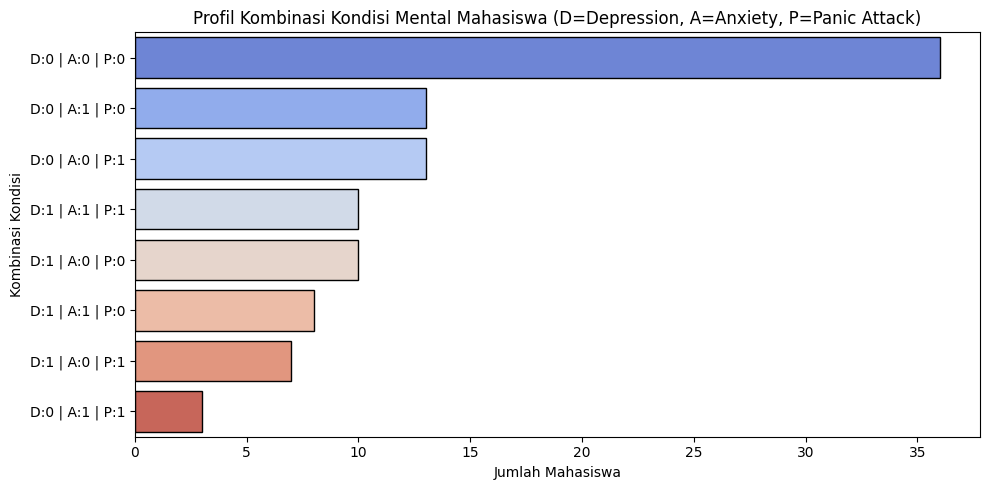

In [35]:
df_temp = df.copy()
df_temp['Depression'] = (df_temp['Depression'] == 'Yes').astype(int)
df_temp['Anxiety'] = (df_temp['Anxiety'] == 'Yes').astype(int)
df_temp['Panic_Attack'] = (df_temp['Panic_Attack'] == 'Yes').astype(int)
df_temp['Profile'] = df_temp.apply(
    lambda r: f"D:{r['Depression']} | A:{r['Anxiety']} | P:{r['Panic_Attack']}", axis=1
)
profile_counts = df_temp['Profile'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=profile_counts.values, y=profile_counts.index, palette='coolwarm', edgecolor='black')
plt.title("Profil Kombinasi Kondisi Mental Mahasiswa (D=Depression, A=Anxiety, P=Panic Attack)")
plt.xlabel("Jumlah Mahasiswa")
plt.ylabel("Kombinasi Kondisi")
plt.tight_layout()
plt.show()


#### Prevalensi Risiko Kesehatan Mental per Jurusan (Top 10)


C:\Users\USER\AppData\Local\Temp\ipykernel_7444\3125500321.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=course_risk.values, y=course_risk.index, palette='Reds_r', edgecolor='black')


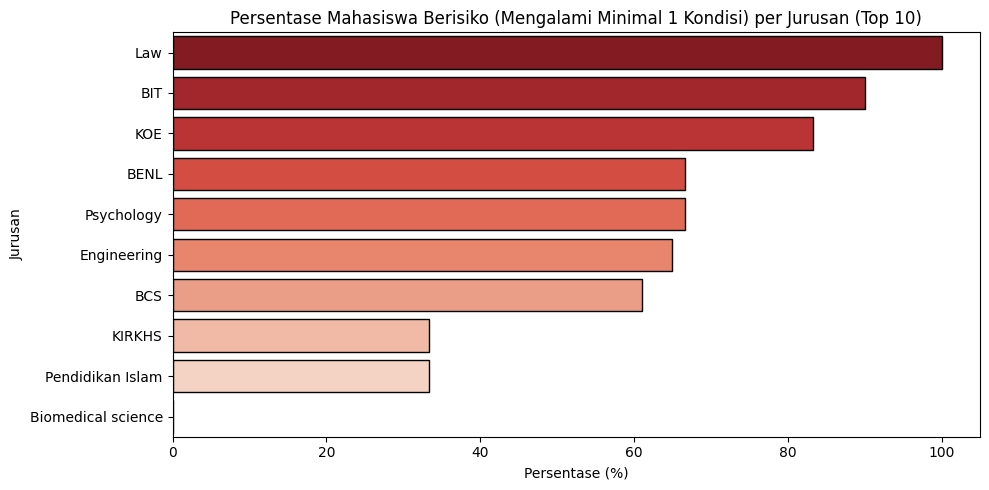

In [36]:
top_10_courses = df['Course'].value_counts().head(10).index
df_top_courses = df[df['Course'].isin(top_10_courses)].copy()
df_top_courses['At_Risk'] = (
    (df_top_courses['Depression'] == 'Yes') | 
    (df_top_courses['Anxiety'] == 'Yes') | 
    (df_top_courses['Panic_Attack'] == 'Yes')
).astype(int)

course_risk = df_top_courses.groupby('Course')['At_Risk'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10, 5))
sns.barplot(x=course_risk.values, y=course_risk.index, palette='Reds_r', edgecolor='black')
plt.title("Persentase Mahasiswa Berisiko (Mengalami Minimal 1 Kondisi) per Jurusan (Top 10)")
plt.xlabel("Persentase (%)")
plt.ylabel("Jurusan")
plt.tight_layout()
plt.show()


#### Analisis Kesenjangan Penanganan (Treatment Gap)


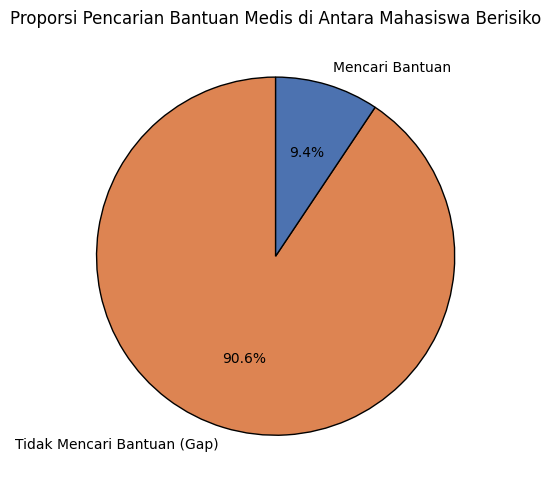

In [37]:
df_gap = df.copy()
df_gap['At_Risk'] = (
    (df_gap['Depression'] == 'Yes') | 
    (df_gap['Anxiety'] == 'Yes') | 
    (df_gap['Panic_Attack'] == 'Yes')
)
df_gap_risk = df_gap[df_gap['At_Risk']]
gap_counts = df_gap_risk['Seek_Treatment'].value_counts()

fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(gap_counts.values, labels=['Tidak Mencari Bantuan (Gap)', 'Mencari Bantuan'], autopct='%1.1f%%', 
       colors=['#DD8452', '#4C72B0'], startangle=90, wedgeprops={'edgecolor': 'black'})
ax.set_title("Proporsi Pencarian Bantuan Medis di Antara Mahasiswa Berisiko")
plt.tight_layout()
plt.show()


#### Matriks Korelasi Cramér's V (Kategorikal)


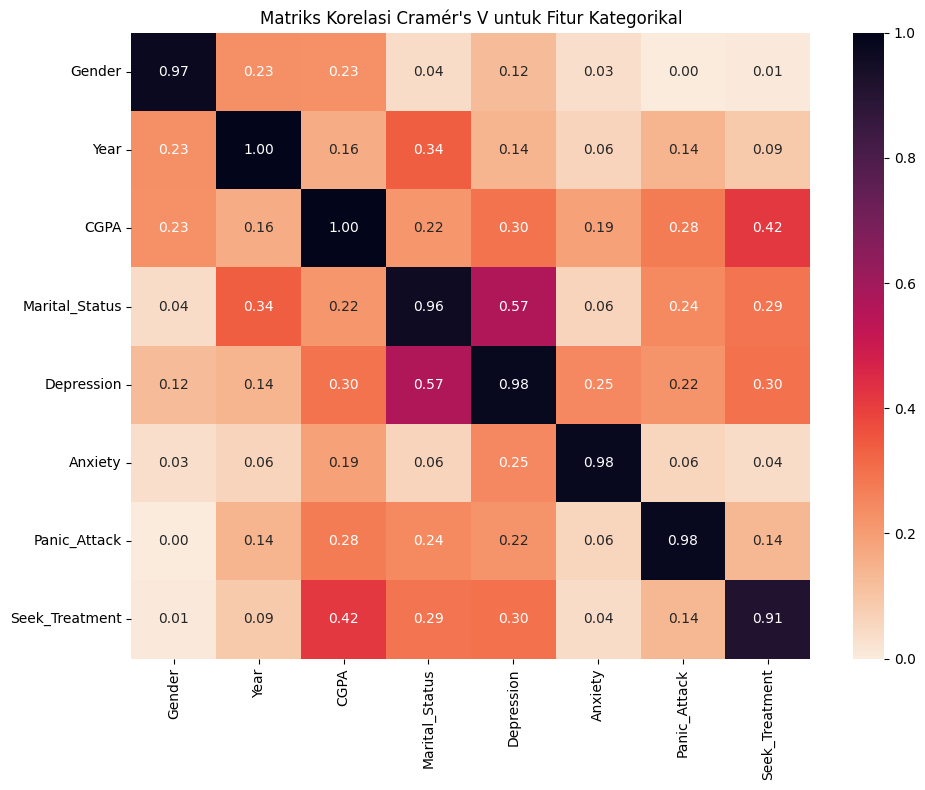

In [38]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * min(r-1, k-1)))

cat_cols = ['Gender', 'Year', 'CGPA', 'Marital_Status', 'Depression', 'Anxiety', 'Panic_Attack', 'Seek_Treatment']
v_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for col1 in cat_cols:
    for col2 in cat_cols:
        v_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])
        
plt.figure(figsize=(10, 8))
sns.heatmap(v_matrix, annot=True, cmap='rocket_r', fmt='.2f', vmin=0, vmax=1)
plt.title("Matriks Korelasi Cramér's V untuk Fitur Kategorikal")
plt.tight_layout()
plt.show()


## Multiclass Output Classifier

### Train Test Split

In [39]:
targets = ["Depression", "Anxiety", "Panic_Attack"]
X = df.drop(columns=targets + ["Course", "Seek_Treatment"])
y = target_encoded[targets]

print(f"Fitur: {list(X.columns)}")
print(f"Target: {list(y.columns)}")


Fitur: ['Gender', 'Age', 'Year', 'CGPA', 'Marital_Status']
Target: ['Depression', 'Anxiety', 'Panic_Attack']


### Label Encoding

In [40]:
# Label encoding dan scaling sekarang ditangani secara dinamis di dalam Pipeline
# untuk menghindari data leakage dan SettingWithCopyWarning.


### Scaling

In [41]:
# Scaling ditangani di dalam Pipeline menggunakan StandardScaler pada kolom Age.


### Modeling

In [42]:
total = len(df)
print(f'Total responden     : {total}')
print(f'Rentang usia        : {int(df["Age"].min())} - {int(df["Age"].max())} tahun')
print(f'Rata-rata usia      : {round(df["Age"].mean(), 2)} tahun')
print(f'Gender dominan      : {df["Gender"].value_counts().idxmax()}')
print(f'Tahun studi terbanyak: {df["Year"].value_counts().idxmax()}')
print(f'CGPA terbanyak      : {df["CGPA"].value_counts().idxmax()}')
print()
for col in ['Depression', 'Anxiety', 'Panic_Attack']:
    yes = (df[col] == 'Yes').sum()
    pct = round(yes / total * 100, 1)
    print(f'{col:30s}: {yes}/{total} ({pct}%)')

# Preprocessing Pipeline setup
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('bin_gen', OrdinalEncoder(categories=[["Male", "Female"]]), ["Gender"]),
        ('bin_mar', OrdinalEncoder(categories=[["No", "Yes"]]), ["Marital_Status"]),
        ('ord_yr', OrdinalEncoder(categories=[["Year 1", "Year 2", "Year 3", "Year 4"]]), ["Year"]),
        ('ord_cgpa', OrdinalEncoder(categories=[["0 - 1.99", "2.00 - 2.49", "2.50 - 2.99", "3.00 - 3.49", "3.50 - 4.00"]]), ["CGPA"]),
        ('num_age', StandardScaler(), ["Age"])
    ]
)


Total responden     : 100
Rentang usia        : 18 - 24 tahun
Rata-rata usia      : 20.54 tahun
Gender dominan      : Female
Tahun studi terbanyak: Year 1
CGPA terbanyak      : 3.50 - 4.00

Depression                    : 35/100 (35.0%)
Anxiety                       : 34/100 (34.0%)
Panic_Attack                  : 33/100 (33.0%)


### SMOTE

In [43]:
# SMOTE sengaja tidak digunakan karena dataset yang kecil (N=100) dan target multi-label.
# Model diatasi menggunakan pembobotan kelas ('class_weight="balanced"') pada pengklasifikasi.


In [44]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import f1_score, hamming_loss
import numpy as np

# Gunakan RepeatedKFold (5 Folds, 3 Repeats) untuk stabilitas evaluasi
rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

models = {
    "Logistic Regression": MultiOutputClassifier(LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
    "Random Forest": MultiOutputClassifier(RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)),
    "Naive Bayes": MultiOutputClassifier(BernoulliNB()),
    "SVM": MultiOutputClassifier(SVC(kernel="linear", class_weight="balanced", probability=True, random_state=42))
}

cv_results = {}
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    
    fold_hammings = []
    fold_f1_macros = []
    fold_f1_weighteds = []
    
    # Kumpulkan out-of-fold predictions
    oof_preds = np.zeros((len(df), len(targets)))
    
    for train_idx, val_idx in rkf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        pipeline.fit(X_tr, y_tr)
        preds = pipeline.predict(X_val)
        
        oof_preds[val_idx] += preds
        
        fold_hammings.append(hamming_loss(y_val, preds))
        fold_f1_macros.append(f1_score(y_val, preds, average='macro', zero_division=0))
        fold_f1_weighteds.append(f1_score(y_val, preds, average='weighted', zero_division=0))
    
    # Voting hasil prediksi cross-validation
    oof_preds_binary = (oof_preds / 3 >= 0.5).astype(int)
    
    cv_results[name] = {
        "hamming_loss": np.mean(fold_hammings),
        "f1_macro": np.mean(fold_f1_macros),
        "f1_weighted": np.mean(fold_f1_weighteds),
        "oof_preds": oof_preds_binary
    }

print(f"{'Model':25s} | {'Hamming Loss':12s} | {'F1 Macro':10s} | {'F1 Weighted':11s}")
print("-" * 68)
for name, res in cv_results.items():
    print(f"{name:25s} | {res['hamming_loss']:.4f}       | {res['f1_macro']:.4f}   | {res['f1_weighted']:.4f}")


Model                     | Hamming Loss | F1 Macro   | F1 Weighted
--------------------------------------------------------------------
Logistic Regression       | 0.4000       | 0.4526   | 0.4673
Random Forest             | 0.3644       | 0.4161   | 0.4264
Naive Bayes               | 0.2889       | 0.3264   | 0.3334
SVM                       | 0.3567       | 0.4518   | 0.4644


### Confusion Matrix

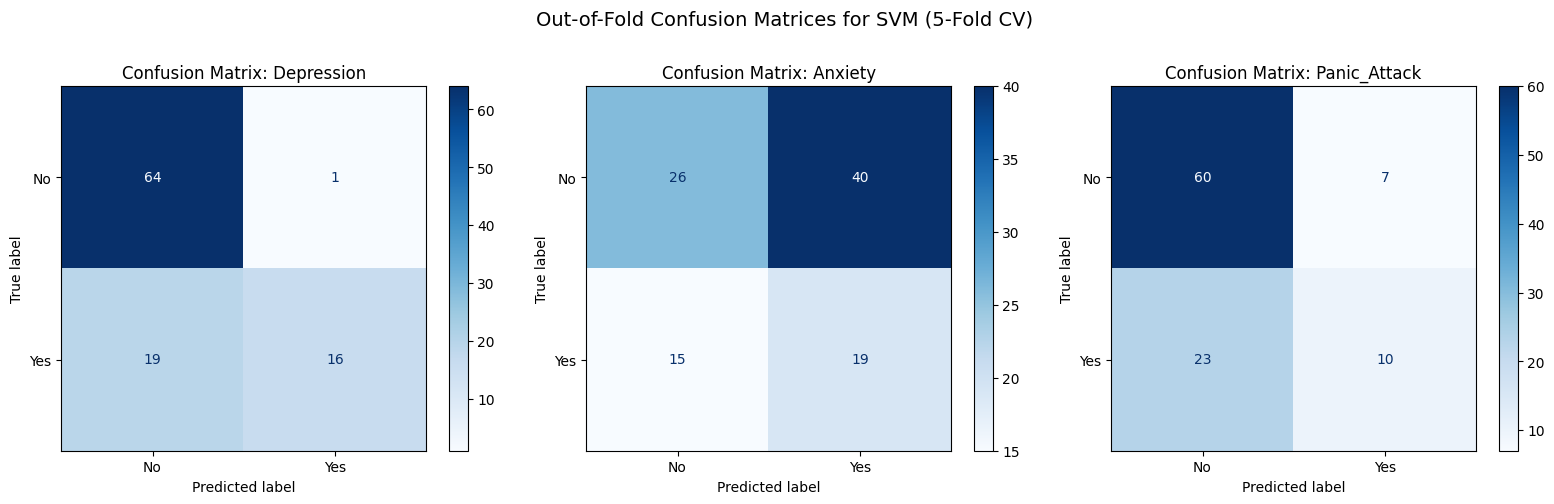

In [45]:
from sklearn.metrics import ConfusionMatrixDisplay
# Plot Confusion Matrix out-of-fold untuk model terbaik (SVM)
best_model_name = "SVM"
best_oof = cv_results[best_model_name]["oof_preds"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for idx, target in enumerate(targets):
    ConfusionMatrixDisplay.from_predictions(
        y.iloc[:, idx], best_oof[:, idx],
        display_labels=['No', 'Yes'],
        cmap='Blues', ax=axes[idx]
    )
    axes[idx].set_title(f'Confusion Matrix: {target}')
plt.suptitle(f'Out-of-Fold Confusion Matrices for {best_model_name} (5-Fold CV)', y=1.05, fontsize=14)
plt.tight_layout()
plt.show()


### Cross-Validation & Feature Importance

In [46]:
from sklearn.metrics import classification_report
# Print classification report detail untuk model terbaik
print(f"Classification Report Detail untuk {best_model_name} (Out-of-Fold Predictions):")
print(classification_report(y, best_oof, target_names=targets, zero_division=0))


Classification Report Detail untuk SVM (Out-of-Fold Predictions):
              precision    recall  f1-score   support

  Depression       0.94      0.46      0.62        35
     Anxiety       0.32      0.56      0.41        34
Panic_Attack       0.59      0.30      0.40        33

   micro avg       0.48      0.44      0.46       102
   macro avg       0.62      0.44      0.47       102
weighted avg       0.62      0.44      0.48       102
 samples avg       0.28      0.26      0.25       102



In [47]:
# Kode cross-validation sebelumnya dihapus untuk menghindari redundansi.
# Kita telah menggunakan RepeatedKFold untuk multi-output classifier.


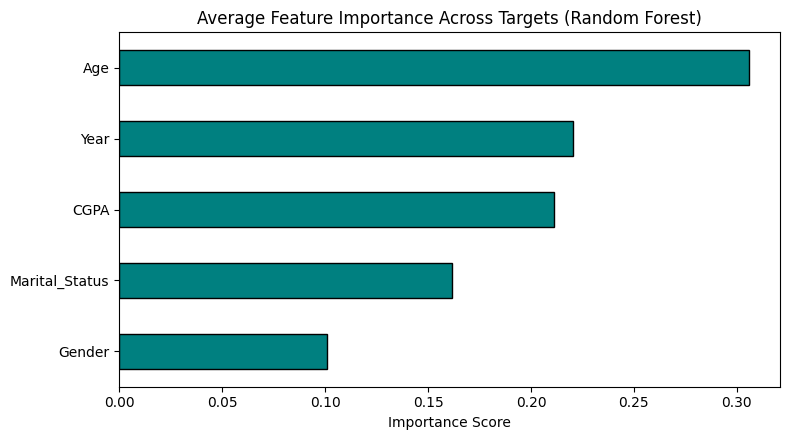


Ranking Feature:
  Age: 0.3057
  Year: 0.2202
  CGPA: 0.2112
  Marital_Status: 0.1618
  Gender: 0.1011


In [48]:
# Plot Feature Importance menggunakan Random Forest utuh (seluruh dataset)
final_rf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', models["Random Forest"])])
final_rf.fit(X, y)

feature_names = ["Gender", "Marital_Status", "Year", "CGPA", "Age"]
rf_classifier = final_rf.named_steps['classifier']
importances = np.mean([est.feature_importances_ for est in rf_classifier.estimators_], axis=0)
importances_df = pd.Series(importances, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(8, 4.5))
importances_df.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Average Feature Importance Across Targets (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nRanking Feature:")
for feat, imp in importances_df.sort_values(ascending=False).items():
    print(f"  {feat}: {imp:.4f}")


## Clustering


In [49]:
# Persiapan data clustering (Salinan terpisah)
df_clust = df.copy()

# Encoding data
df_clust["Gender"]         = df_clust["Gender"].map({"Male": 0, "Female": 1})
df_clust["Marital_Status"] = df_clust["Marital_Status"].map({"No": 0, "Yes": 1})
df_clust["Depression"]     = df_clust["Depression"].map({"No": 0, "Yes": 1})
df_clust["Anxiety"]        = df_clust["Anxiety"].map({"No": 0, "Yes": 1})
df_clust["Panic_Attack"]   = df_clust["Panic_Attack"].map({"No": 0, "Yes": 1})
df_clust["Seek_Treatment"] = df_clust["Seek_Treatment"].map({"No": 0, "Yes": 1})

year_order = [["Year 1", "Year 2", "Year 3", "Year 4"]]
cgpa_order = [["0 - 1.99", "2.00 - 2.49", "2.50 - 2.99", "3.00 - 3.49", "3.50 - 4.00"]]

df_clust["Year"] = OrdinalEncoder(categories=year_order).fit_transform(df_clust[["Year"]])
df_clust["CGPA"] = OrdinalEncoder(categories=cgpa_order).fit_transform(df_clust[["CGPA"]])

demo_features = ["Gender", "Age", "Year", "CGPA", "Marital_Status"]
demo_mh_features = ["Gender", "Age", "Year", "CGPA", "Marital_Status", "Depression", "Anxiety", "Panic_Attack"]

X_demo = df_clust[demo_features].copy()
X_demo_mh = df_clust[demo_mh_features].copy()

# Standardize features for KMeans and DBSCAN
scaler_demo = StandardScaler()
scaler_demo_mh = StandardScaler()

X_demo_scaled = scaler_demo.fit_transform(X_demo)
X_demo_scaled_df = pd.DataFrame(X_demo_scaled, columns=demo_features)

X_demo_mh_scaled = scaler_demo_mh.fit_transform(X_demo_mh)
X_demo_mh_scaled_df = pd.DataFrame(X_demo_mh_scaled, columns=demo_mh_features)

print("Demo features shape    :", X_demo_scaled.shape)
print("Demo + MH features shape:", X_demo_mh_scaled.shape)


Demo features shape    : (100, 5)
Demo + MH features shape: (100, 8)


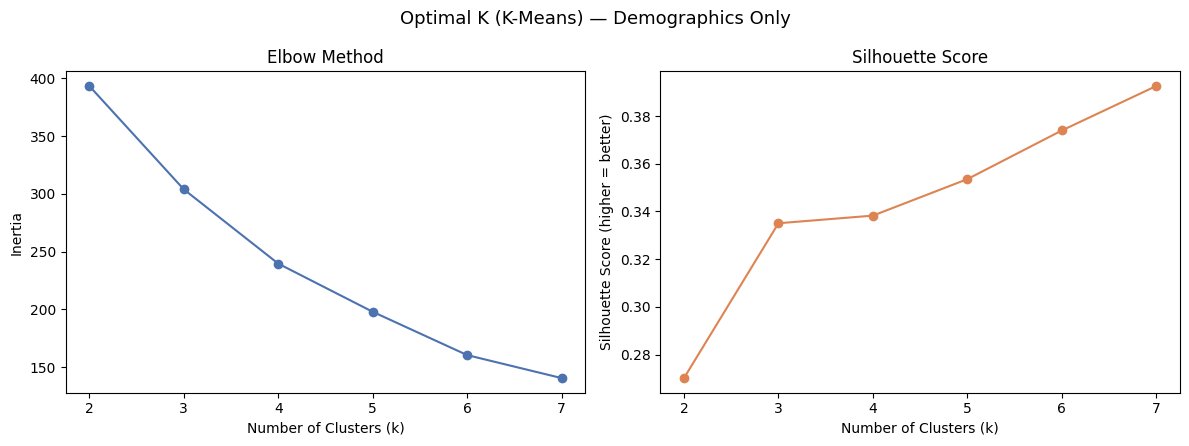

Best k by silhouette: 7 (score: 0.3926)


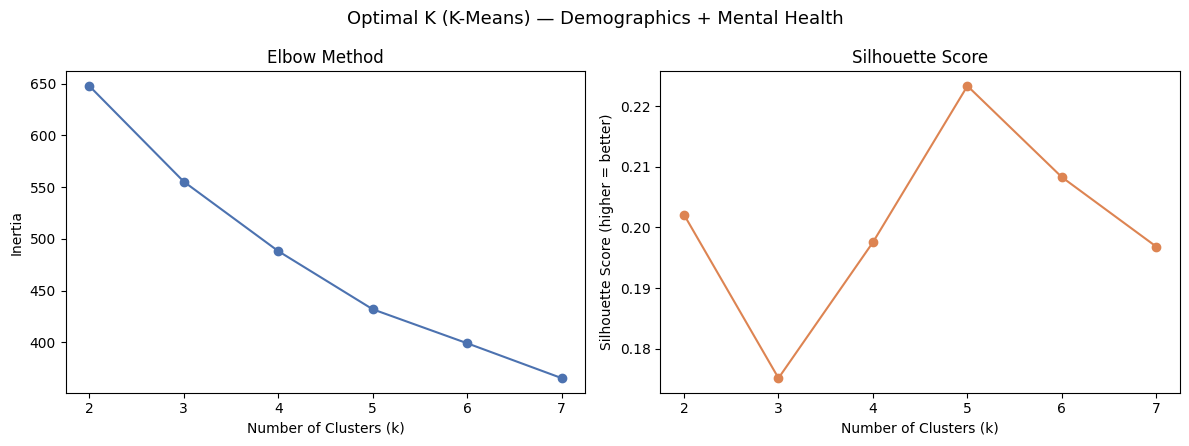

Best k by silhouette: 5 (score: 0.2233)


In [50]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def find_optimal_k_kmeans(X_scaled, title, k_range=range(2, 8)):
    inertias, silhouettes = [], []

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_scaled)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_scaled, labels))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    fig.suptitle(f"Optimal K (K-Means) — {title}", fontsize=13)

    axes[0].plot(k_range, inertias, marker="o", color="#4C72B0")
    axes[0].set_title("Elbow Method")
    axes[0].set_xlabel("Number of Clusters (k)")
    axes[0].set_ylabel("Inertia")

    axes[1].plot(k_range, silhouettes, marker="o", color="#DD8452")
    axes[1].set_title("Silhouette Score")
    axes[1].set_xlabel("Number of Clusters (k)")
    axes[1].set_ylabel("Silhouette Score (higher = better)")

    plt.tight_layout()
    plt.show()

    best_k = list(k_range)[silhouettes.index(max(silhouettes))]
    print(f"Best k by silhouette: {best_k} (score: {max(silhouettes):.4f})")
    return best_k

best_k_demo    = find_optimal_k_kmeans(X_demo_scaled,    "Demographics Only")
best_k_demo_mh = find_optimal_k_kmeans(X_demo_mh_scaled, "Demographics + Mental Health")


In [51]:
# Perform K-Means clustering (k=3 as predefined)
km_demo_mh = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clust["Cluster_KMeans"] = km_demo_mh.fit_predict(X_demo_mh_scaled)

print("\nCluster_KMeans distribution:")
print(df_clust["Cluster_KMeans"].value_counts().sort_index())



Cluster_KMeans distribution:
Cluster_KMeans
0    41
1    16
2    43
Name: count, dtype: int64


In [52]:
def profile_clusters(df, cluster_col, features):
    print(f"\n{'='*60}")
    print(f"  Cluster Profiles — {cluster_col}")
    print(f"{'='*60}")
    profile = df.groupby(cluster_col)[features + ["Seek_Treatment"]].mean().round(2)
    print(profile.T)
    return profile

profile_kmeans = profile_clusters(df_clust, "Cluster_KMeans", demo_mh_features)



  Cluster Profiles — Cluster_KMeans
Cluster_KMeans      0      1      2
Gender           0.85   0.81   0.60
Age             19.02  21.12  21.77
Year             0.41   1.50   1.26
CGPA             3.59   3.31   2.95
Marital_Status   0.00   1.00   0.00
Depression       0.44   1.00   0.02
Anxiety          0.54   0.44   0.12
Panic_Attack     0.37   0.62   0.19
Seek_Treatment   0.05   0.25   0.00


In [53]:
from sklearn.metrics import adjusted_rand_score
from itertools import combinations

# Cek stabilitas K-Means dengan seed acak
labels_list = []
for seed in [0, 1, 42, 99, 123]:
    km = KMeans(n_clusters=3, random_state=seed, n_init=10)
    labels_list.append(km.fit_predict(X_demo_mh_scaled))

scores = [adjusted_rand_score(a, b) for a, b in combinations(labels_list, 2)]
print(f"K-Means Stability ARI: {np.mean(scores):.4f} ± {np.std(scores):.4f}")


K-Means Stability ARI: 0.8944 ± 0.0307


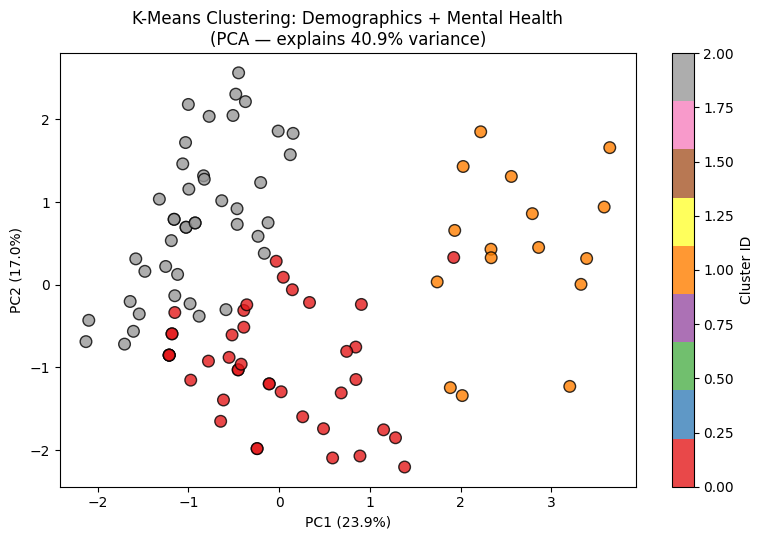

In [54]:
from sklearn.decomposition import PCA

def plot_clusters(X_scaled, labels, title):
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X_scaled)
    variance = pca.explained_variance_ratio_

    plt.figure(figsize=(8, 5.5))
    scatter = plt.scatter(coords[:, 0], coords[:, 1],
                          c=labels, cmap="Set1", alpha=0.8, edgecolors="k", s=70)
    plt.colorbar(scatter, label="Cluster ID")
    plt.title(f"{title}\n(PCA — explains {variance.sum()*100:.1f}% variance)")
    plt.xlabel(f"PC1 ({variance[0]*100:.1f}%)")
    plt.ylabel(f"PC2 ({variance[1]*100:.1f}%)")
    plt.tight_layout()
    plt.show()

plot_clusters(X_demo_mh_scaled, df_clust["Cluster_KMeans"], "K-Means Clustering: Demographics + Mental Health")


In [55]:
from sklearn.cluster import DBSCAN

# Tuning DBSCAN parameters (eps and min_samples)
dbscan_results = []
for eps in np.arange(0.5, 3.1, 0.25):
    for min_samples in range(2, 7):
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_demo_mh_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        if n_clusters > 1:
            score = silhouette_score(X_demo_mh_scaled, labels)
            dbscan_results.append({
                "eps": eps,
                "min_samples": min_samples,
                "n_clusters": n_clusters,
                "n_noise": n_noise,
                "silhouette_score": score
            })

import pandas as pd
tuning_df = pd.DataFrame(dbscan_results)
print("Top 5 DBSCAN configurations by Silhouette Score:")
print(tuning_df.sort_values(by="silhouette_score", ascending=False).head(5))


Top 5 DBSCAN configurations by Silhouette Score:
     eps  min_samples  n_clusters  n_noise  silhouette_score
6   1.25            2          23       26          0.314188
11  1.50            2          21       21          0.293261
16  1.75            2          21       14          0.273811
21  2.00            2          20       10          0.272325
32  2.50            3           2        8          0.231474


In [56]:
# Fit DBSCAN dengan konfigurasi terbaik (misal: eps=1.75, min_samples=3)
# Parameter dipilih agar jumlah cluster wajar (bukan 1 cluster) dan noise minimal
best_eps = 1.75
best_min = 3
db_demo_mh = DBSCAN(eps=best_eps, min_samples=best_min)
df_clust["Cluster_DBSCAN"] = db_demo_mh.fit_predict(X_demo_mh_scaled)

print("\nCluster_DBSCAN distribution (-1 represents noise/outliers):")
print(df_clust["Cluster_DBSCAN"].value_counts().sort_index())



Cluster_DBSCAN distribution (-1 represents noise/outliers):
Cluster_DBSCAN
-1     34
 0      3
 1      4
 2      3
 3      3
 4      7
 5     25
 6      5
 7      5
 8      5
 9      3
 10     3
Name: count, dtype: int64


In [57]:
# Profile DBSCAN clusters
profile_dbscan = profile_clusters(df_clust, "Cluster_DBSCAN", demo_mh_features)



  Cluster Profiles — Cluster_DBSCAN
Cluster_DBSCAN    -1      0      1      2      3      4      5     6     7   \
Gender           0.65   0.00   1.00   0.00   0.00   1.00   1.00   1.0   0.0   
Age             20.82  21.00  21.00  23.33  20.33  18.86  20.76  19.4  20.2   
Year             1.03   0.67   1.75   2.33   0.67   0.71   0.92   0.2   0.4   
CGPA             2.97   3.00   3.25   3.67   4.00   3.86   3.44   3.2   3.0   
Marital_Status   0.26   0.00   1.00   0.00   0.00   0.00   0.00   0.0   0.0   
Depression       0.59   0.00   1.00   0.00   0.00   0.00   0.00   1.0   0.0   
Anxiety          0.53   1.00   0.00   0.00   0.00   1.00   0.00   0.0   0.0   
Panic_Attack     0.56   0.00   0.00   0.00   1.00   0.00   0.00   0.0   0.0   
Seek_Treatment   0.15   0.00   0.00   0.00   0.00   0.00   0.00   0.0   0.0   

Cluster_DBSCAN    8      9      10  
Gender           1.0   1.00   1.00  
Age             18.2  24.00  18.67  
Year             1.0   2.00   0.00  
CGPA             3.4   3

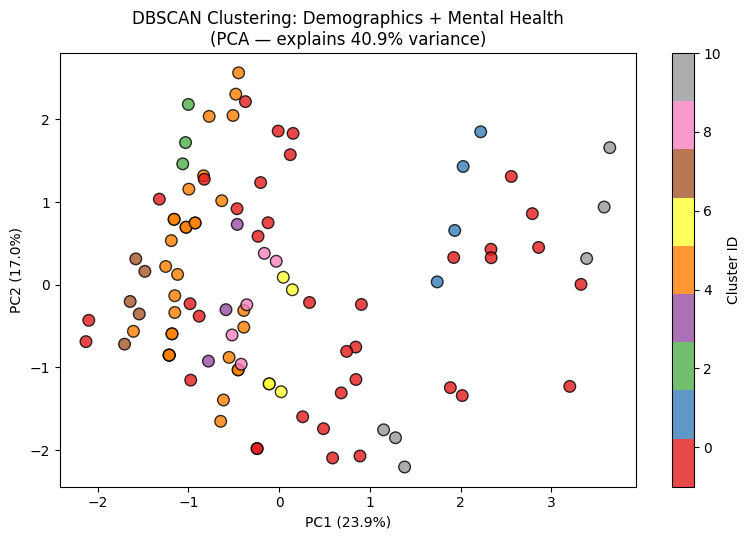

In [58]:
# Plot DBSCAN clusters in PCA space
plot_clusters(X_demo_mh_scaled, df_clust["Cluster_DBSCAN"], "DBSCAN Clustering: Demographics + Mental Health")


In [59]:
# Bandingkan performa visual dan jumlah cluster K-Means vs DBSCAN
print("Distribusi K-Means  :\n", df_clust["Cluster_KMeans"].value_counts().sort_index())
print("\nDistribusi DBSCAN   :\n", df_clust["Cluster_DBSCAN"].value_counts().sort_index())


Distribusi K-Means  :
 Cluster_KMeans
0    41
1    16
2    43
Name: count, dtype: int64

Distribusi DBSCAN   :
 Cluster_DBSCAN
-1     34
 0      3
 1      4
 2      3
 3      3
 4      7
 5     25
 6      5
 7      5
 8      5
 9      3
 10     3
Name: count, dtype: int64


## Risk Scoring


In [60]:
def risk_score(row):
    conditions = (
        (row["Depression"] == "Yes") +
        (row["Anxiety"] == "Yes") +
        (row["Panic_Attack"] == "Yes")
    )
    if conditions == 0:
        return "Low"
    elif conditions == 1:
        return "Medium"
    else:
        return "High"

df["Risk_Score"] = df.apply(risk_score, axis=1)

# Also add a binary treatment gap flag — useful for Page 2
df["Treatment_Gap"] = (
    (df["Risk_Score"].isin(["Medium", "High"])) &
    (df["Seek_Treatment"] == "No")
).map({True: "Gap", False: "No Gap"})

df.to_csv("mental_health_cleaned.csv", index=False)

In [61]:
df.head()

,Gender,Age,Course,Year,CGPA,Marital_Status,Depression,Anxiety,Panic_Attack,Seek_Treatment,Risk_Score,Treatment_Gap
0,Female,18.0,Engineering,Year 1,3.00 - 3.49,No,Yes,No,Yes,No,High,Gap
1,Male,21.0,Islamic Education,Year 2,3.00 - 3.49,No,No,Yes,No,No,Medium,Gap
2,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No,High,Gap
3,Female,22.0,Law,Year 3,3.00 - 3.49,Yes,Yes,No,No,No,Medium,Gap
4,Male,23.0,Mathemathics,Year 4,3.00 - 3.49,No,No,No,No,No,Low,No Gap
